In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print('All libraries imported successfully!')

All libraries imported successfully!


In [10]:
# Load dataset
df = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (15079, 5)

First 5 rows:


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [11]:
# Basic information
print('Dataset Info:')
print(df.info())
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB
None

Statistical Summary:


,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [12]:
# Check missing values
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nDuplicate Rows:', df.duplicated().sum())
print('\nGender Distribution:')
print(df['Gender'].value_counts())

Missing Values per Column:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

Duplicate Rows: 0

Gender Distribution:
Gender
Male      7595
Female    7484
Name: count, dtype: int64


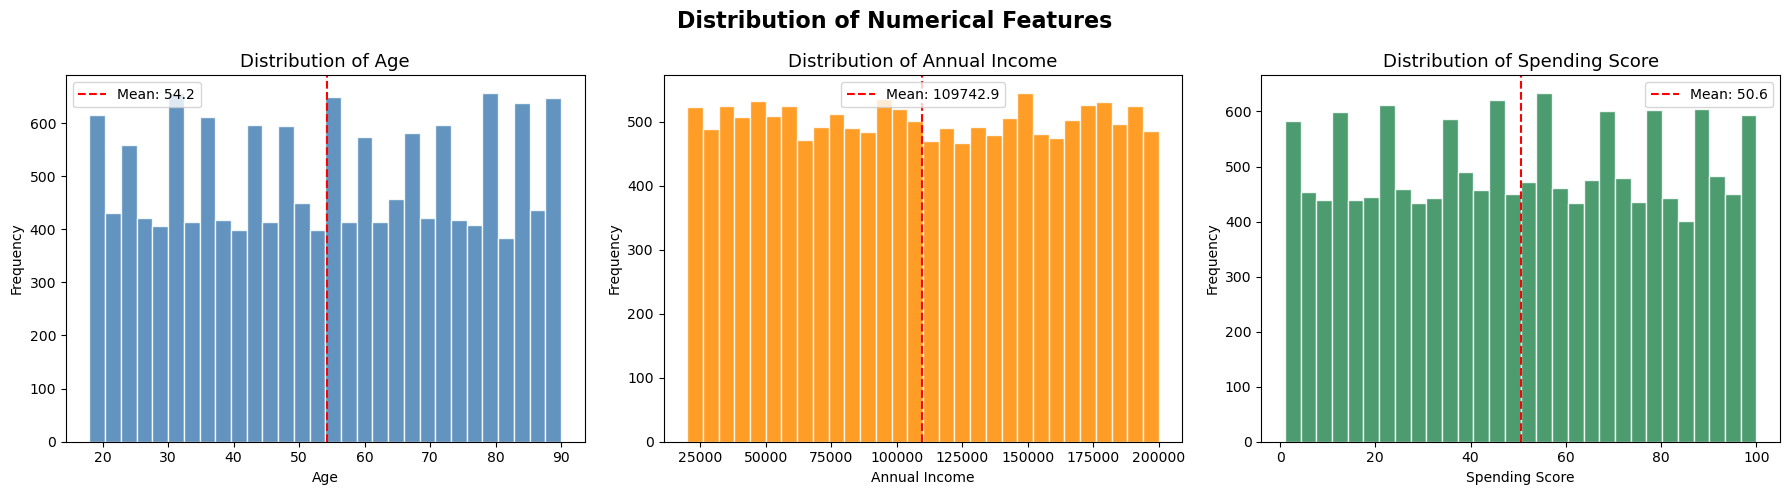

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

colors = ['steelblue', 'darkorange', 'seagreen']
cols = ['Age', 'Annual Income', 'Spending Score']

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

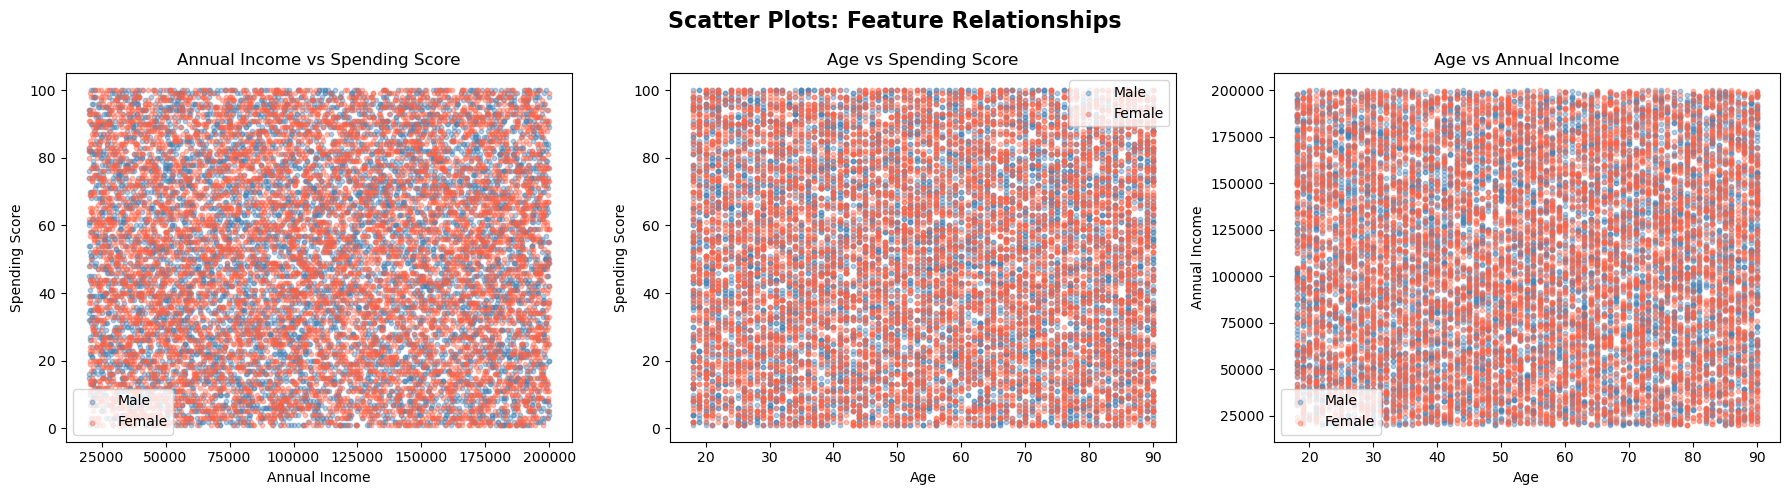

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatter Plots: Feature Relationships', fontsize=16, fontweight='bold')

palette = {'Male': 'steelblue', 'Female': 'tomato'}

pairs = [
    ('Annual Income', 'Spending Score'),
    ('Age', 'Spending Score'),
    ('Age', 'Annual Income'),
]

for ax, (x, y) in zip(axes, pairs):
    for gender, color in palette.items():
        mask = df['Gender'] == gender
        ax.scatter(df[mask][x], df[mask][y], c=color, label=gender, alpha=0.4, s=10)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

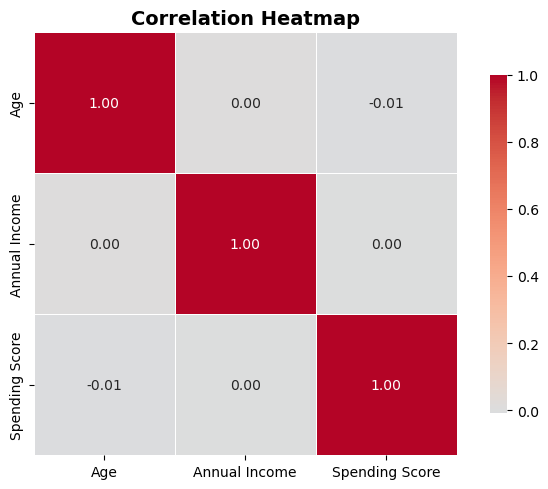

In [15]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[['Age', 'Annual Income', 'Spending Score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Step 1: Drop Customer ID (not useful for clustering)
df_clean = df.drop(columns=['Customer ID'])

# Step 2: Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print('Gender encoding: Female=0, Male=1')
print(df_clean['Gender'].value_counts())

# Step 3: Feature Scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clean.columns)

print('\nScaled Data (first 3 rows):')
print(X_scaled_df.head(3))
print('\nShape of scaled data:', X_scaled.shape)

Gender encoding: Female=0, Male=1
Gender
1    7595
0    7484
Name: count, dtype: int64

Scaled Data (first 3 rows):
        Age    Gender  Annual Income  Spending Score
0 -1.145516  0.992666       0.798813        1.337059
1  0.180335 -1.007389       1.442076        1.545929
2  0.369742 -1.007389      -0.743208        0.884507

Shape of scaled data: (15079, 4)


In [17]:
# Step 4: Dimensionality Reduction with PCA (for visualization)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('PCA Explained Variance Ratio:', pca.explained_variance_ratio_)
print(f'Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%')

# We will use Annual Income & Spending Score as main clustering features (most informative)
# and full scaled data for DBSCAN
X_main = X_scaled[:, [2, 3]]  # Annual Income, Spending Score (after encoding)
print('\nMain features for clustering: Annual Income & Spending Score')

PCA Explained Variance Ratio: [0.25248591 0.25074522]
Total Variance Explained: 50.32%

Main features for clustering: Annual Income & Spending Score
